In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches
from glob import glob

from skimage import io
import os, sys
import matplotlib
from scipy.optimize import curve_fit
matplotlib.rcParams.update({'errorbar.capsize': 4})


In [8]:
ROOT_DIR = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/'
FILTER_PATH = ROOT_DIR +'/code/imag_analisis/filter_stats.csv'
filtAv = pd.read_csv(FILTER_PATH).central_lambda[:10]
filtUn = pd.read_csv(FILTER_PATH).range_width[:10]
filtQE = pd.read_csv(FILTER_PATH).mean_qe[:10]

In [233]:
def exp_func2(x, a, b, c, d, e):
    return a * np.exp(-x / b) + c * np.exp(-x / d) + e

def get_exposure_time(path):
    """Get the exposure time from the settings file.
    Args: path: string with the path to the directory with the settings file.
    Returns: texp: float with the exposure time.
    """
    file_settings = path + '/settings.json'
    df_settings = pd.read_csv(file_settings, sep=':', names=['setting', 'value'], index_col='setting')

    texp = float(df_settings.loc['EXPOSURE_TIME'].values[0])
    return texp

def get_power(path_file):
    """Get the exposure time from the settings file.
    Args: path: string with the path to the directory with the settings file.
    Returns: texp: float with the exposure time.
    """
    string_power = path_file.split('/')[-1].split('_')[-1]
    power_uW = float(string_power[:-6])

    return power_uW

In [ ]:
def calculate_trajectories(files, roi, baseline_subtraction = True, power_correction = True):
    """Calculate the average intensity of the images in a list of files.
    Args: files: list of strings with the paths to the images.
          mask: 2D numpy array with the binary mask of the field of view.
          roi_size: integer with the number of pixels in the field of view.
    Returns: avg_ints: 1D numpy array with the average intensity values.
    """

    light_baseline = 6.020880e+06

    avg_counts = []
    std_counts = []
    sum_counts = []
    results_df = pd.DataFrame()
    for n, f in enumerate(files):
        power = get_power(f)
        img = io.imread(f).astype(np.int64)
        img = img[roi[0]:roi[1], roi[2]:roi[3]]

        img_size = img.shape[0] * img.shape[1]
        sum_img = img.sum()
        if (n >= 136) and (baseline_subtraction):
            sum_img = img.sum() - light_baseline
            
        mean_img = sum_img / img_size
        std_img = img.std() / np.sqrt(img.size)
        if power_correction:
            mean_img = mean_img / power
            std_img = std_img / power
            sum_img = sum_img / power

        avg_counts.append(mean_img)
        std_counts.append(std_img)
        sum_counts.append(sum_img)

    results_df['avg_counts'] = avg_counts
    results_df['std_counts'] = std_counts
    results_df['sum_counts'] = sum_counts

    return results_df

def fit_plot_trajectories(time_array, results_roi, color = None, label = None, ax = None):
    bs = results_roi['avg_counts'].iloc[-1]

    par2, _ = curve_fit(exp_func2, time_array, results_roi['avg_counts'],  p0=(11.77, 7.23, 18.6, 0.775, bs))

    if ax == None: ax = plt.gca()
    if label == None: label='Rhodamine B 50 µM'

    line = ax.errorbar(time_array, results_roi['avg_counts'], 
             yerr=results_roi['std_counts'], 
             zorder = 1,
             fmt='.', color=color, label=label)[0]

    color = line.get_color()
    ax.plot(time_array, exp_func2(time_array, *par2), '-', color=color, lw=2, zorder = 3,
         label=f'{par2[0]:.1f} exp(-t/ {par2[1]:.1f}) + {par2[2]:.1f} exp(-t/ {par2[3]:.1f}) + {par2[4]:.0f}')
    ax.legend()
    ax.set(xlabel='time (min)', ylabel='Avg. counts/uW', title='Fluorescence trajectories')
    return color

In [301]:
def plot_roi(img, roi, color='red'):
    # imroi = img[roi[0]:roi[1], roi[2]:roi[3]]
    ax = plt.gca()
    ax.imshow(img)
    ax.add_patch(patches.Rectangle((roi[2], roi[0]), roi[3]-roi[2], roi[1]-roi[0], fill=False, 
                                   edgecolor=color, linewidth=2 ))

# Rhodamine 50 µM

## Define common variables:

In [146]:
path_rhb50 = ROOT_DIR + 'data/img/time/08-04-25/Rhodamine-B 50 µM 270225/1-filt7-575nm'
files = sorted(glob(path_rhb50 + '/*.tif'))

frame_nr = np.arange(len(files))
time_array = frame_nr * get_exposure_time(path_rhb50)
time_array_min = frame_nr * get_exposure_time(path_rhb50) / 60

In [421]:
string_time0 = files[0].split('/')[-1].split('_')[2]
# power_uW = float(string_power[:-6])
time0 = pd.to_datetime(string_time0, format='%H-%M-%S')
times_save = []
for f in files:
    string_time = f.split('/')[-1].split('_')[2]
    delta_time = pd.to_datetime(string_time, format='%H-%M-%S') - time0
    times_save.append(delta_time.total_seconds() / 60)

times_save = np.array(times_save)
times_save[-5:], time_array_min[-5:]

(array([69.63333333, 69.81666667, 70.        , 70.16666667, 70.35      ]),
 array([32.91666667, 33.        , 33.08333333, 33.16666667, 33.25      ]))

#### Saving time is approximately 2x that of the step time

In [ ]:
powers = []
for f in files:
    power = get_power(f)
    powers.append(power)
mean_power = np.mean(powers)

# Calculate trajectories for different roi sizes

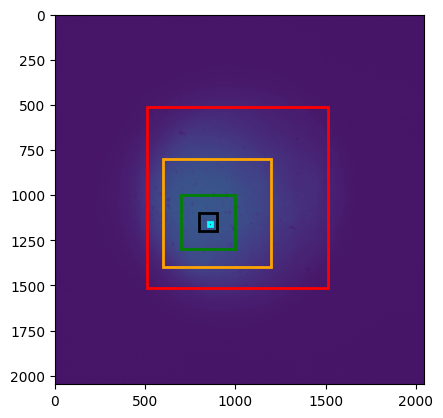

In [ ]:
img = io.imread(files[0]).astype(np.int64)
roi_full = [0,2048, 0,2048]
roi1 = [512, 1512, 512, 1512]
roi2 = [800, 1400, 600, 1200]
roi3 = [1000, 1300, 700, 1000]
roi4 = [1100, 1200, 800, 900]
roi5 = [1150, 1170, 850, 870]

plot_roi(img, roi1, color = 'r')
plot_roi(img, roi2, color = 'orange')
plot_roi(img, roi3, color = 'g')
plot_roi(img, roi4, color = 'k')
plot_roi(img, roi5, color = 'cyan')

[(1000.0, 1300.0), (700.0, 1000.0)]

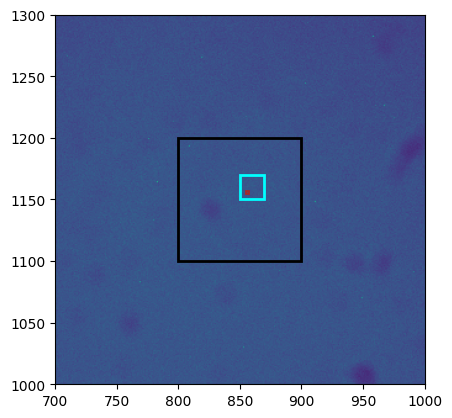

In [393]:
roi4 = [1100, 1200, 800, 900]
roi5 = [1150, 1170, 850, 870]
roi6 = [1155, 1157, 855, 857]
plot_roi(img, roi4, color = 'k')
plot_roi(img, roi5, color = 'cyan')
plot_roi(img, roi6, color = 'brown')
plt.gca().set(ylim=(roi3[0], roi3[1]), xlim=(roi3[2], roi3[3]))

In [ ]:
results_full_roi = calculate_trajectories(files, roi_full, baseline_subtraction=True, power_correction=True) * mean_power
results_roi1 = calculate_trajectories(files, roi1, baseline_subtraction=True, power_correction=True) * mean_power

In [328]:
results_roi2 = calculate_trajectories(files, roi2, baseline_subtraction=False, power_correction=True) * mean_power
results_roi3 = calculate_trajectories(files, roi3, baseline_subtraction=False, power_correction=True) * mean_power
results_roi4 = calculate_trajectories(files, roi4, baseline_subtraction=False, power_correction=True) * mean_power
results_roi5 = calculate_trajectories(files, roi5, baseline_subtraction=False, power_correction=True) * mean_power
results_roi6 = calculate_trajectories(files, roi6, baseline_subtraction=False, power_correction=True) * mean_power

'b'

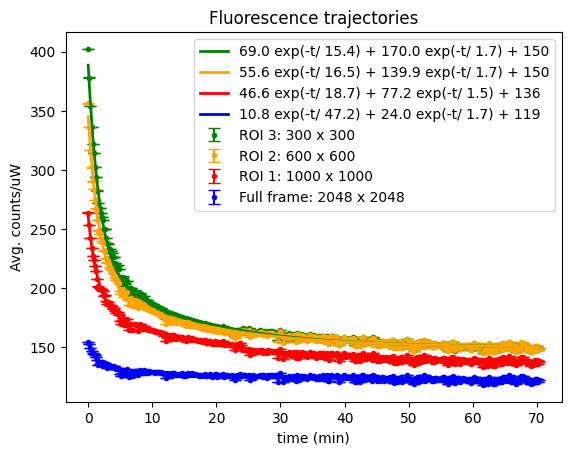

In [423]:
fit_plot_trajectories(times_save, results_roi3, color='g',
                       label = 'ROI 3: {} x {}'.format(roi3[1] - roi3[0], roi3[3] - roi3[2]))
fit_plot_trajectories(times_save, results_roi2, color='orange', 
                      label = 'ROI 2: {} x {}'.format(roi2[1] - roi2[0], roi2[3] - roi2[2]))
fit_plot_trajectories(times_save, results_roi1, color='r', 
                      label = 'ROI 1: {} x {}'.format(roi1[1] - roi1[0], roi1[3] - roi1[2]))
fit_plot_trajectories(times_save, results_full_roi, color='b', 
                      label = 'Full frame: {} x {}'.format(roi_full[1] - roi_full[0], roi_full[3] - roi_full[2]))

# col3 = fit_plot_trajectories(times_save, results_roi3, label = 'ROI 3')
# col4 = fit_plot_trajectories(times_save, results_roi4, label = 'ROI 4')
# col5 = fit_plot_trajectories(times_save, results_roi5, label = 'ROI 5')
# col6 = fit_plot_trajectories(times_save, results_roi6, label = 'ROI 6')

'g'

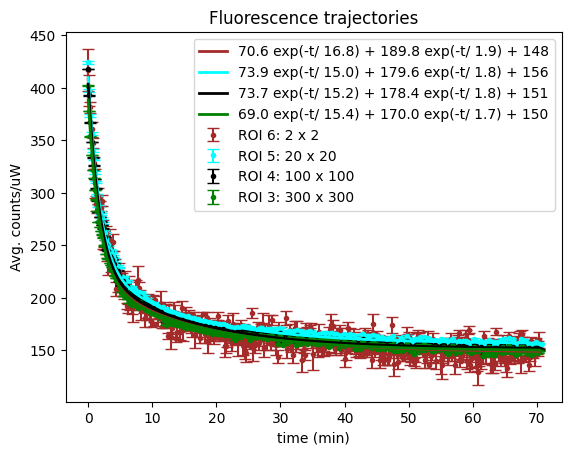

In [422]:
fit_plot_trajectories(times_save, results_roi6, color='brown',
                       label = 'ROI 6: {} x {}'.format(roi6[1] - roi6[0], roi6[3] - roi6[2]))
fit_plot_trajectories(times_save, results_roi5, color='cyan',
                       label = 'ROI 5: {} x {}'.format(roi5[1] - roi5[0], roi5[3] - roi5[2]))
fit_plot_trajectories(times_save, results_roi4, color='k',
                       label = 'ROI 4: {} x {}'.format(roi4[1] - roi4[0], roi4[3] - roi4[2]))
fit_plot_trajectories(times_save, results_roi3, color='g',
                       label = 'ROI 3: {} x {}'.format(roi3[1] - roi3[0], roi3[3] - roi3[2]))

# Rhodamine 5 µM

## Define common variables:

In [451]:
path_rhb5 = ROOT_DIR + 'data/img/time/10-04-25/Rhodamine-B 5 µM 270225/1-filt7-575nm'
files5 = sorted(glob(path_rhb5 + '/*.tif'))

frame_nr = np.arange(len(files5))
time_array = frame_nr * get_exposure_time(path_rhb5)
time_array_min = frame_nr * get_exposure_time(path_rhb5) / 60

In [452]:
string_time0 = files5[0].split('/')[-1].split('_')[2]
# power_uW = float(string_power[:-6])
time0 = pd.to_datetime(string_time0, format='%H-%M-%S')
times_save = []
for f in files5:
    string_time = f.split('/')[-1].split('_')[2]
    delta_time = pd.to_datetime(string_time, format='%H-%M-%S') - time0
    times_save.append(delta_time.total_seconds() / 60)

times_save = np.array(times_save)
times_save[-5:], time_array_min[-5:]

(array([17.1       , 17.13333333, 17.18333333, 17.21666667, 17.26666667]),
 array([13.16666667, 13.2       , 13.23333333, 13.26666667, 13.3       ]))

In [453]:
powers = []
for f in files5:
    power = get_power(f)
    powers.append(power)
mean_power = np.mean(powers)
mean_power

457.13241274999996

## Trajectories for different ROI size

In [454]:
results5_full_roi = calculate_trajectories(files5, roi_full, baseline_subtraction=False, power_correction=True) * mean_power
results5_roi1 = calculate_trajectories(files5, roi1, baseline_subtraction=False, power_correction=True) * mean_power
results5_roi2 = calculate_trajectories(files5, roi2, baseline_subtraction=False, power_correction=True) * mean_power
results5_roi3 = calculate_trajectories(files5, roi3, baseline_subtraction=False, power_correction=True) * mean_power
results5_roi4 = calculate_trajectories(files5, roi4, baseline_subtraction=False, power_correction=True) * mean_power
results5_roi5 = calculate_trajectories(files5, roi5, baseline_subtraction=False, power_correction=True) * mean_power
results5_roi6 = calculate_trajectories(files5, roi6, baseline_subtraction=False, power_correction=True) * mean_power

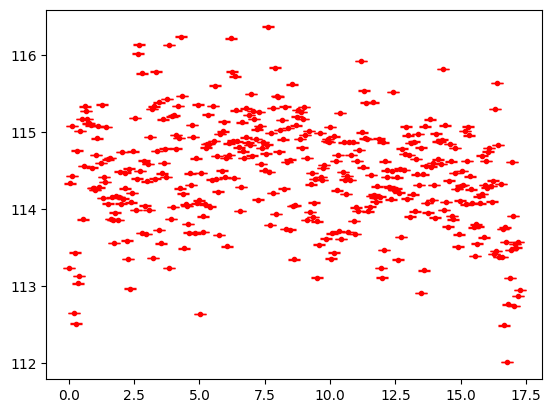

In [455]:
ax = plt.gca()
line = ax.errorbar(times_save, results5_full_roi['avg_counts'], 
             yerr=results5_full_roi['std_counts'], 
             zorder = 1,
             fmt='.', color='r', label=None)[0]

In [ ]:
# fit_plot_trajectories(times_save, results5_roi3, color='g',
                    #    label = 'ROI 3: {} x {}'.format(roi3[1] - roi3[0], roi3[3] - roi3[2]))
# fit_plot_trajectories(times_save, results5_roi2, color='orange', 
#                       label = 'ROI 2: {} x {}'.format(roi2[1] - roi2[0], roi2[3] - roi2[2]))
# fit_plot_trajectories(times_save, results5_roi1, color='r', 
#                       label = 'ROI 1: {} x {}'.format(roi1[1] - roi1[0], roi1[3] - roi1[2]))
# fit_plot_trajectories(times_save, results5_full_roi, color='b', 
#                       label = 'Full frame: {} x {}'.format(roi_full[1] - roi_full[0], roi_full[3] - roi_full[2]))

# col3 = fit_plot_trajectories(times_save, results_roi3, label = 'ROI 3')
# col4 = fit_plot_trajectories(times_save, results_roi4, label = 'ROI 4')
# col5 = fit_plot_trajectories(times_save, results_roi5, label = 'ROI 5')
# col6 = fit_plot_trajectories(times_save, results_roi6, label = 'ROI 6')

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1200.

# Analysis methodology:

## Correcting for background lab light baseline:

In [ ]:
results_no_baseline = calculate_trajectories(files, roi_full, baseline_subtraction=False, power_correction=False)
results_light_baseline = calculate_trajectories(files, roi_full, baseline_subtraction=True, power_correction=False)

In [ ]:
before_lights, after_lights = results_full_roi.iloc[135]['sum_counts'], results_full_roi.iloc[136]['sum_counts']
difference = after_lights - before_lights
difference = 6.020880e+06
print(f'Before lights: {before_lights:1e}, After lights: {after_lights:1e}, difference: {difference:1e}')

Before lights: 5.233909e+08, After lights: 5.294117e+08, difference: 6.020880e+06


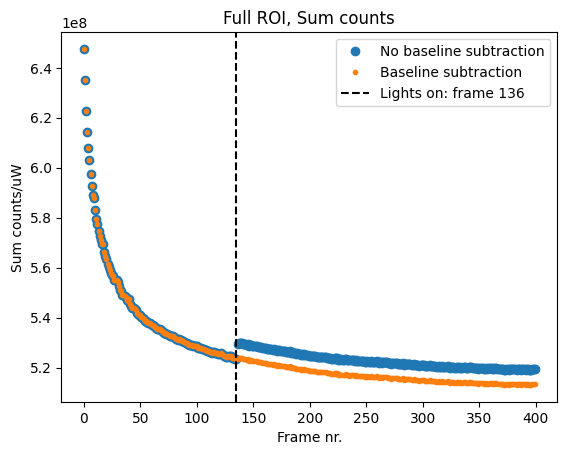

In [153]:
plt.plot(range(len(files)), results_no_baseline['sum_counts'], 'o', label='No baseline subtraction')
plt.plot(range(len(files)), results_light_baseline['sum_counts'], '.', label='Baseline subtraction')
plt.axvline(135, color='k', linestyle='--', label='Lights on: frame 136')
plt.gca().set(xlabel='Frame nr.', ylabel='Sum counts/uW', title='Full ROI, Sum counts')#, xlim=(130, 140), ylim=(5.2e8, 5.4e8))
plt.legend()

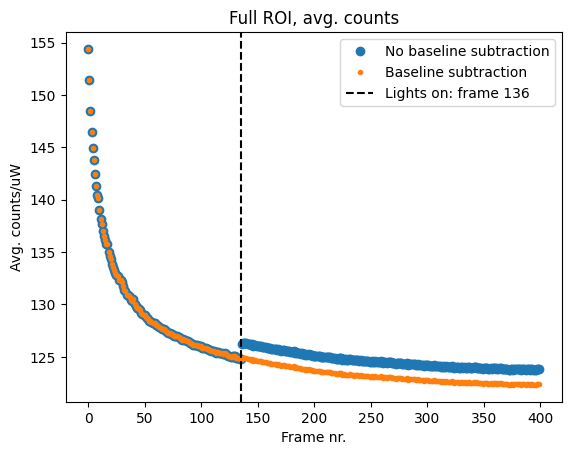

In [152]:
plt.plot(range(len(files)), results_no_baseline['avg_counts'], 'o', label='No baseline subtraction')
plt.plot(range(len(files)), results_light_baseline['avg_counts'], '.', label='Baseline subtraction')
plt.axvline(135, color='k', linestyle='--', label='Lights on: frame 136')
plt.gca().set(xlabel='Frame nr.', ylabel='Avg. counts/uW', title='Full ROI, avg. counts')#, xlim=(130, 140), ylim=(5.2e8, 5.4e8))
plt.legend()

## Power correction

In [130]:
results_no_power = calculate_trajectories(files, roi_full, baseline_subtraction=True, power_correction=False)
results_power_corrected = calculate_trajectories(files, roi_full, baseline_subtraction=True, power_correction=True)

In [ ]:
powers = []
for f in files:
    power = get_power(f)
    powers.append(power)
mean_power = np.mean(powers)

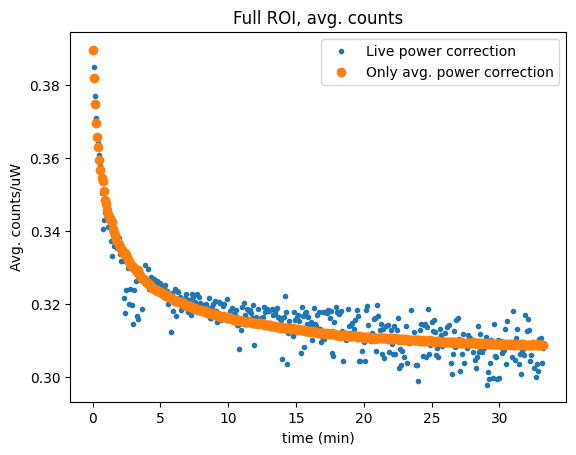

In [395]:
plt.plot(time_array_min, results_power_corrected['avg_counts'], '.', label='Live power correction')
plt.plot(time_array_min, results_no_power['avg_counts']/mean_power, 'o', label='Only avg. power correction')
plt.gca().set(xlabel='time (min)', ylabel='Avg. counts/uW', title='Full ROI, avg. counts')#, xlim=(130, 140), ylim=(5.2e8, 5.4e8))
plt.legend()

## Exponential fits

In [227]:
results_full_roi = calculate_trajectories(files, roi_full, baseline_subtraction=True, power_correction=False)

In [220]:
def exp_func1(x, a, b, c):
    return a * np.exp(-x / b) + c

def exp_func2(x, a, b, c, d, e):
    return a * np.exp(-x / b) + c * np.exp(-x / d) + e

bs = results_full_roi['avg_counts'].iloc[-1]
par1, pcov1 = curve_fit(exp_func1, time_array_min, results_full_roi['avg_counts'],  p0=(22.30, 3.127, bs))
par2, pcov2 = curve_fit(exp_func2, time_array_min, results_full_roi['avg_counts'],  p0=(22.30, 3.127, 0.1, 0.02, bs))

par1, par2

(array([ 22.30479664,   3.12735908, 123.26199527]),
 array([ 11.77624191,   7.23510794,  18.60764232,   0.77532672,
        122.38095428]))

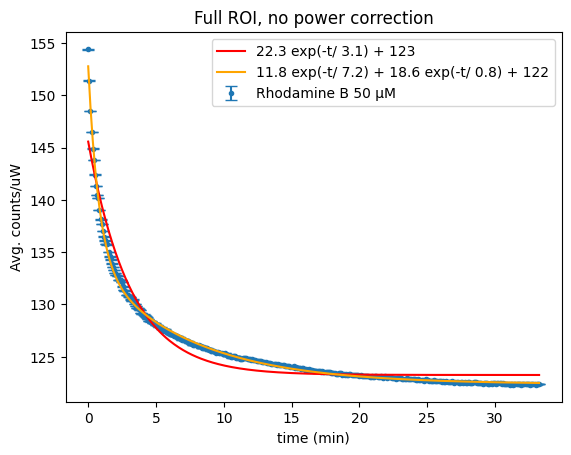

In [231]:
plt.errorbar(time_array_min, results_full_roi['avg_counts'], 
             yerr=results_full_roi['std_counts'], 
             zorder = 1,
             fmt='.', label='Rhodamine B 50 µM')

plt.plot(time_array_min, exp_func1(time_array_min, *par1), 'r-', zorder = 2,
         label=f'{par1[0]:.1f} exp(-t/ {par1[1]:.1f}) + {par1[2]:.0f}')
plt.plot(time_array_min, exp_func2(time_array_min, *par2), '-', color='orange', zorder = 3,
         label=f'{par2[0]:.1f} exp(-t/ {par2[1]:.1f}) + {par2[2]:.1f} exp(-t/ {par2[3]:.1f}) + {par2[4]:.0f}')
plt.gca().set(xlabel='time (min)', ylabel='Avg. counts/uW', title='Full ROI, no power correction')
plt.legend()

In [228]:
results_full_roi_power = calculate_trajectories(files, roi_full, baseline_subtraction=True, power_correction=True)
results_full_roi_power *= mean_power


In [428]:
bs = results_full_roi['avg_counts'].iloc[-1]
ppar1, ppcov1 = curve_fit(exp_func1, time_array_min, results_full_roi_power['avg_counts'],  p0=(22.30, 3.127, bs))
ppar2, ppcov2 = curve_fit(exp_func2, time_array_min, results_full_roi_power['avg_counts'],  p0=(11.77, 7.23, 18.60, 0.77, bs))

ppar1, ppar2

(array([ 21.53673199,   2.70663185, 123.62254281]),
 array([ 10.84063537,  22.32970932,  24.10786065,   0.78173836,
        119.16186779]))

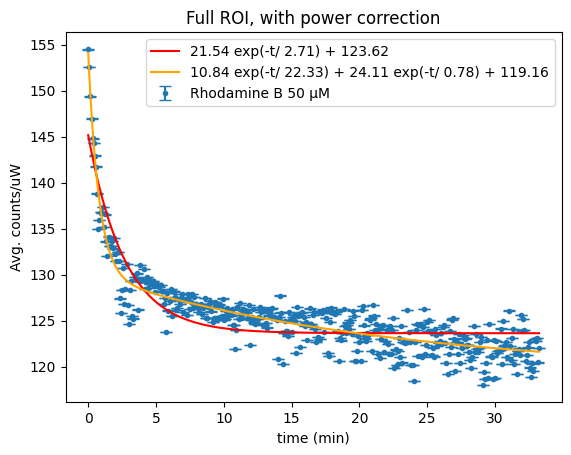

In [232]:
plt.errorbar(time_array_min, results_full_roi_power['avg_counts'],
              yerr=results_full_roi_power['std_counts'], fmt='.', 
              zorder=1,
              label='Rhodamine B 50 µM')

plt.plot(time_array_min, exp_func1(time_array_min, *ppar1), 'r-', zorder = 2,
         label=f'{ppar1[0]:.2f} exp(-t/ {ppar1[1]:.2f}) + {ppar1[2]:.2f}')
plt.plot(time_array_min, exp_func2(time_array_min, *ppar2), '-', color='orange', zorder = 3,
         label=f'{ppar2[0]:.2f} exp(-t/ {ppar2[1]:.2f}) + {ppar2[2]:.2f} exp(-t/ {ppar2[3]:.2f}) + {ppar2[4]:.2f}')
plt.gca().set(xlabel='time (min)', ylabel='Avg. counts/uW', title='Full ROI, with power correction')
plt.legend()

## Save time vs step time

Save time is approximately 2x the step time

In [419]:
string_time0 = files[0].split('/')[-1].split('_')[2]
# power_uW = float(string_power[:-6])
time0 = pd.to_datetime(string_time0, format='%H-%M-%S')
times_save = []
for f in files:
    string_time = f.split('/')[-1].split('_')[2]
    delta_time = pd.to_datetime(string_time, format='%H-%M-%S') - time0
    times_save.append(delta_time.total_seconds() / 60)

times_save = np.array(times_save)
times_save[:5], time_array_min[:5]

(array([0.        , 0.16666667, 0.35      , 0.51666667, 0.7       ]),
 array([0.        , 0.08333333, 0.16666667, 0.25      , 0.33333333]))

In [426]:
ppar_ts, ppcov_ts = curve_fit(exp_func2, times_save, results_full_roi_power['avg_counts'],  p0=(11.77, 7.23, 18.60, 0.77, bs))

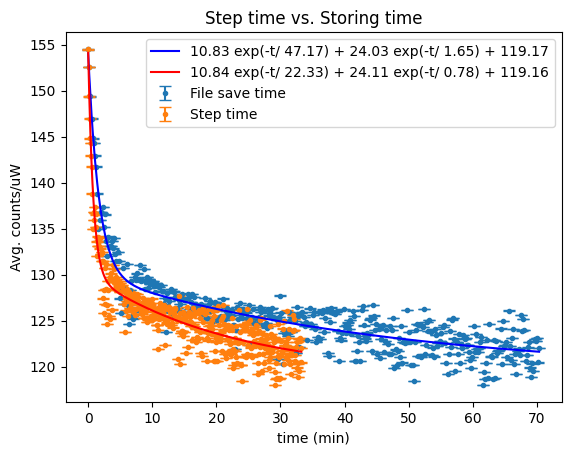

In [432]:
plt.errorbar(times_save, results_full_roi_power['avg_counts'],
              yerr=results_full_roi_power['std_counts'], fmt='.', 
              zorder=1,
              label='File save time')

plt.plot(times_save, exp_func2(times_save, *ppar_ts), '-', color='b', zorder = 3,
         label=f'{ppar_ts[0]:.2f} exp(-t/ {ppar_ts[1]:.2f}) + {ppar_ts[2]:.2f} exp(-t/ {ppar_ts[3]:.2f}) + {ppar_ts[4]:.2f}')

plt.errorbar(time_array_min, results_full_roi_power['avg_counts'],
              yerr=results_full_roi_power['std_counts'], fmt='.', 
              zorder=1,
              label='Step time')

plt.plot(time_array_min, exp_func2(time_array_min, *ppar2), '-', color='r', zorder = 3,
         label=f'{ppar2[0]:.2f} exp(-t/ {ppar2[1]:.2f}) + {ppar2[2]:.2f} exp(-t/ {ppar2[3]:.2f}) + {ppar2[4]:.2f}')

plt.gca().set(xlabel='time (min)', ylabel='Avg. counts/uW', title='Step time vs. Storing time')
plt.legend()